In [22]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/deepi1507/predict-customer-churn/Chrun train.csv
/kaggle/input/datasets/deepi1507/predict-customer-churn/Churn test.csv


## Domain Analysis ##

**Customer Churn Prediction**

Customer churn refers to customers discontinuing a company’s services. It is a major concern in industries like telecom, banking, and SaaS, where retaining customers is more cost-effective than acquiring new ones.
Companies such as Netflix, Amazon, and Airtel use churn prediction to identify customers likely to leave and take preventive actions.

**Objective**
The objective of churn analysis is to build a model that predicts whether a customer will churn based on factors like demographics, service usage, tenure, and billing details.
Key drivers of churn include:
Short tenure (new customers)
Month-to-month contracts
High monthly charges
Lack of additional services
Churn prediction helps businesses reduce revenue loss, improve customer retention, and increase customer lifetime value by enabling targeted strategies such as personalized offers and improved customer support.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [24]:
data = pd.read_csv('/kaggle/input/datasets/deepi1507/predict-customer-churn/Chrun train.csv')
test = pd.read_csv('/kaggle/input/datasets/deepi1507/predict-customer-churn/Churn test.csv')


****Basic Checks****

In [25]:
data.shape

(594194, 21)

In [26]:
data.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [27]:
data.tail()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
594189,594189,Male,0,No,No,57,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Two year,No,Bank transfer (automatic),97.55,5460.70,No
594190,594190,Female,0,No,No,72,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Bank transfer (automatic),91.95,6782.15,No
594191,594191,Female,0,Yes,No,72,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),24.40,1871.90,No
594192,594192,Female,0,No,No,32,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,86.00,2847.20,No
594193,594193,Female,1,Yes,No,2,Yes,No,DSL,No,...,No,No,Yes,No,Month-to-month,Yes,Electronic check,54.55,108.05,Yes


In [28]:
data.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  PaperlessBilling  59

In [30]:
data.duplicated().sum()

np.int64(0)

In [31]:
data.isnull().sum()

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [32]:
data.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [33]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
id,594194.0,297096.500000,171529.177262,0.00,148548.25,297096.50,445644.75,594193.00
SeniorCitizen,594194.0,0.114102,0.317936,0.00,0.00,0.00,0.00,1.00
tenure,594194.0,36.577258,25.061922,1.00,12.00,35.00,62.00,72.00
MonthlyCharges,594194.0,65.866223,31.067444,18.25,29.90,74.10,90.80,118.75
TotalCharges,594194.0,2494.377057,2353.916710,18.80,639.65,1433.65,4263.80,8684.80


**Exploratory Data Analysis(EDA)**

**Univariate Analysis**

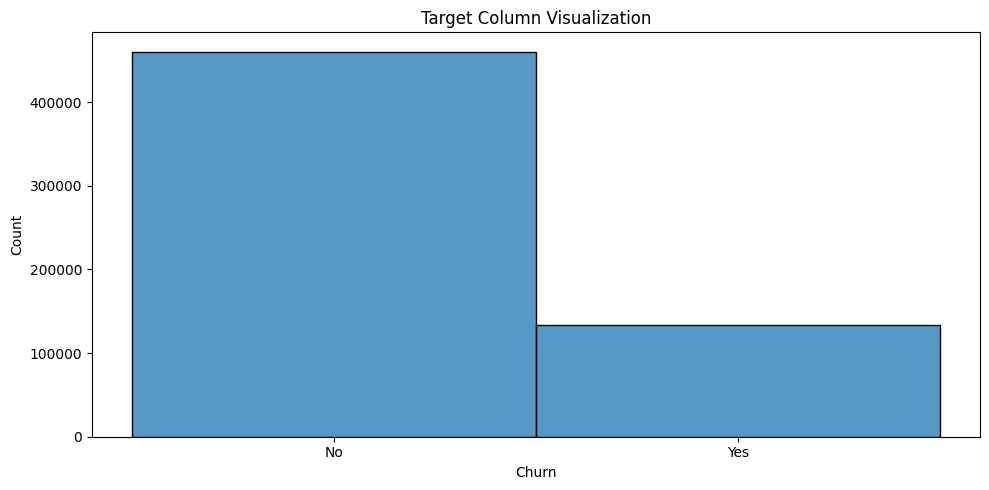

In [34]:
plt.figure(figsize=(10,5))
target = data['Churn']
sns.histplot(target)
plt.title('Target Column Visualization')
plt.tight_layout()
plt.show()

**Insights:**
This plot shows that most of the customer is not returning so,this is an highly imbalanced data.

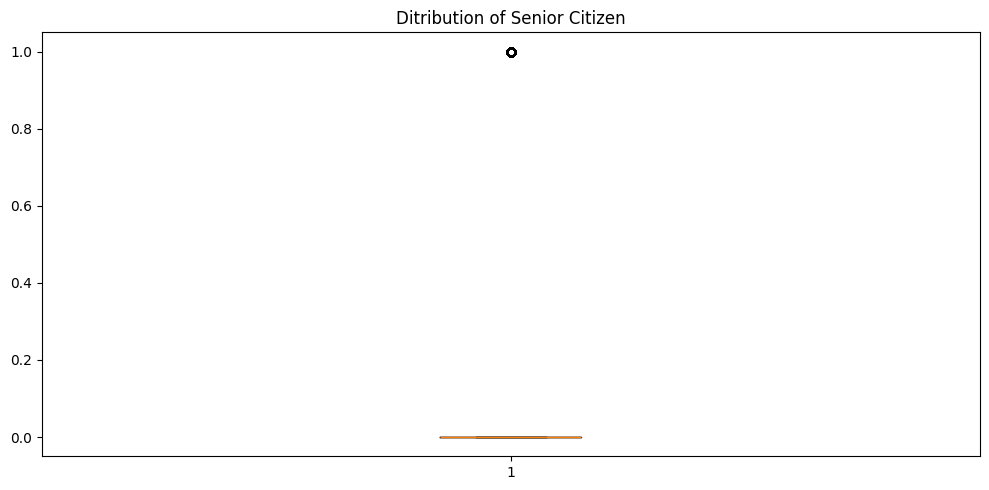

In [35]:
plt.figure(figsize=(10,5))
plt.boxplot(data['SeniorCitizen'])
plt.title('Ditribution of Senior Citizen')
plt.tight_layout()
plt.show()

**Insights:**
This plot shows that,this column is having outliers(i.e.it is having some far away data point),it cause an effect on whole data so need to handle it.

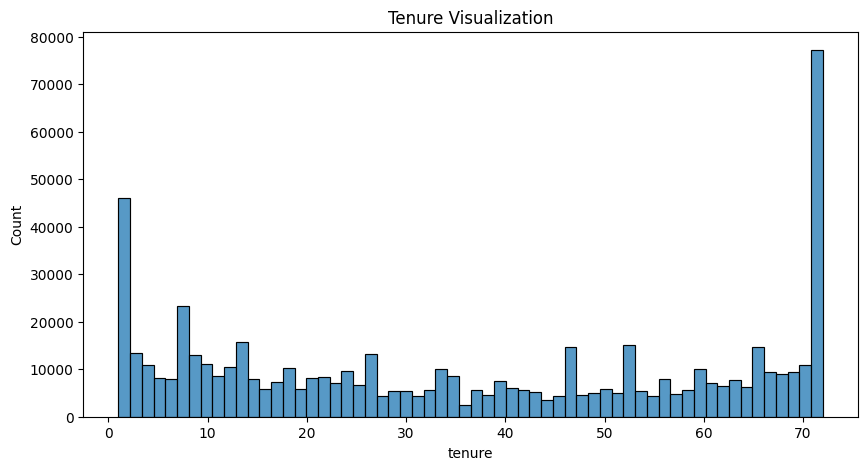

In [36]:
plt.figure(figsize=(10,5))
sns.histplot(data['tenure'])
plt.title('Tenure Visualization')
plt.show()

**Insights:**
The distribution shows a U-shaped pattern with two major spikes
Spike 1 (0-1 months): 46,000 new customers who are at the highest churn risk
Spike 2 (72 months):77,000 long-term loyal customers who rarely churn
Middle tenure customers (20-60 months) are relatively fewer.
Customers either leave quickly or stay forever very little middle ground
The first month is the most critical period for customer retention
If a customer crosses 1 year, they tend to stay much longer

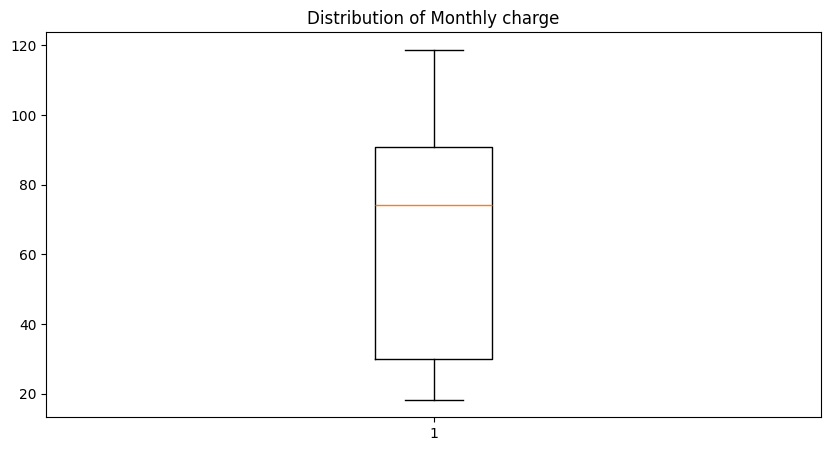

In [37]:
plt.figure(figsize=(10,5))
plt.boxplot(data['MonthlyCharges'])
plt.title('Distribution of Monthly charge')
plt.show()

**Inisghts:**
The monthly charges range from 20 to 120, with a median of around
74, indicating that most customers pay relatively high monthly bills.
The interquartile range (IQR) falls between 35 and 90, showing a
wide spread in pricing across the customer base. There are no outliers
detected, suggesting the pricing structure is consistent with no
extreme anomalies.

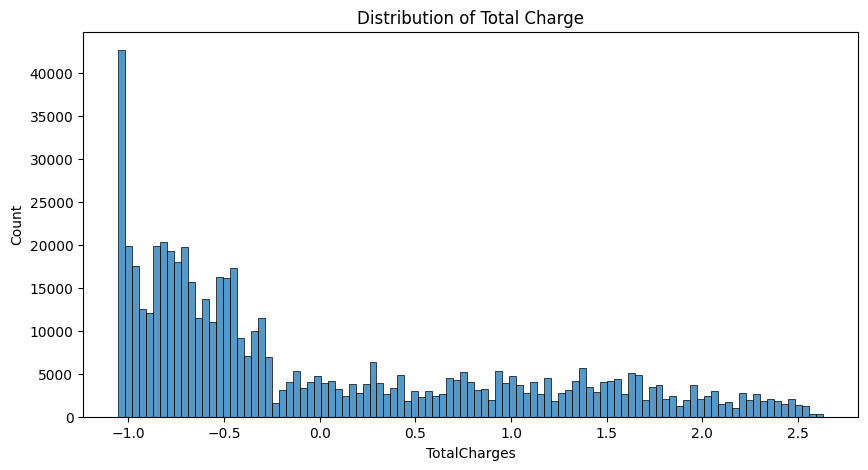

In [61]:
plt.figure(figsize=(10,5))
sns.histplot(data['TotalCharges'])
plt.title('Distribution of Total Charge')
plt.show()

**Insights:**
The total charges distribution is heavily right-skewed, with the highest concentration of customers (~42,000) having very low total
charges near $0-$100, indicating a large number of new customers.
The distribution gradually decreases as total charges increase, with
a long tail extending up to $8,500, representing long-term customers
who have accumulated higher bills over time. This skewness directly aligns with the tenure pattern new customers dominate the low total charges range while loyal long-term customers make up the higher end.

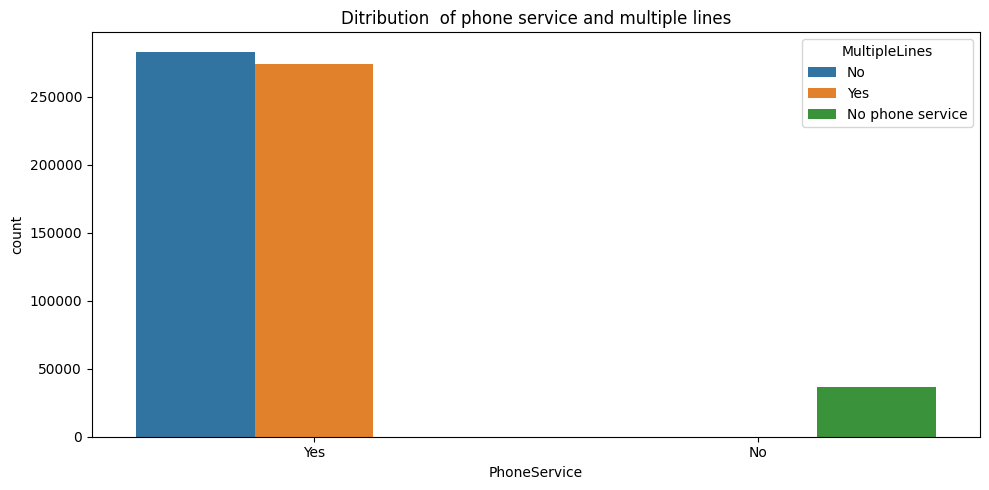

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(x='PhoneService',hue='MultipleLines',data=data)
plt.title('Ditribution  of phone service and multiple lines')
plt.tight_layout()
plt.show()

**Insights:**
The majority of customers (280,000) have phone service, with an
almost equal split between those having single line (No) and multiple
lines (Yes), indicating strong phone service adoption across the
customer base. Customers without phone service (37,000) form a very
small group, and naturally fall under the "No phone service" category
for multiple lines. This shows that phone service is a core product
for this telecom company with nearly 94% of customers subscribed to it.

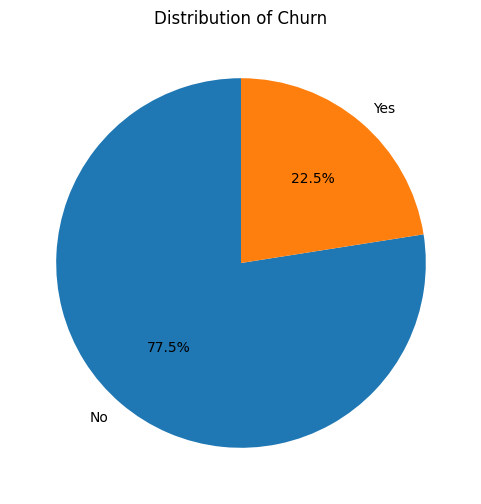

In [40]:
plt.figure(figsize=(6,6))
data['Churn'].value_counts().plot(kind='pie',startangle=90,autopct='%1.1f%%')
plt.title('Distribution of Churn')
plt.ylabel('')
plt.show()

**Insights:**
Most customers (77.5%) stay, while 22.5% chrn, showing a moderate class imbalance(~3.1). The model should handle this imbalance using techniques like class weighting.

**Bivariate Analysis**

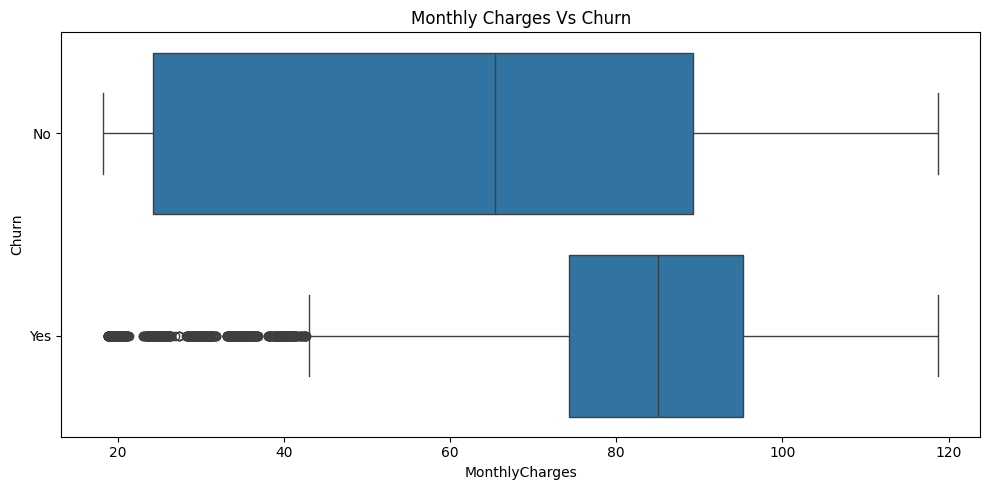

In [41]:
plt.figure(figsize=(10,5))
sns.boxplot(x='MonthlyCharges',y='Churn',data=data)
plt.title('Monthly Charges Vs Churn')
plt.tight_layout()
plt.show()

**Insights:**
Customers with high monthly charges ($70+) are most likely to churn, while mid-range customers($45-$70)are more stable.A small group of low-paying customers also churn, possibly due to service issues.

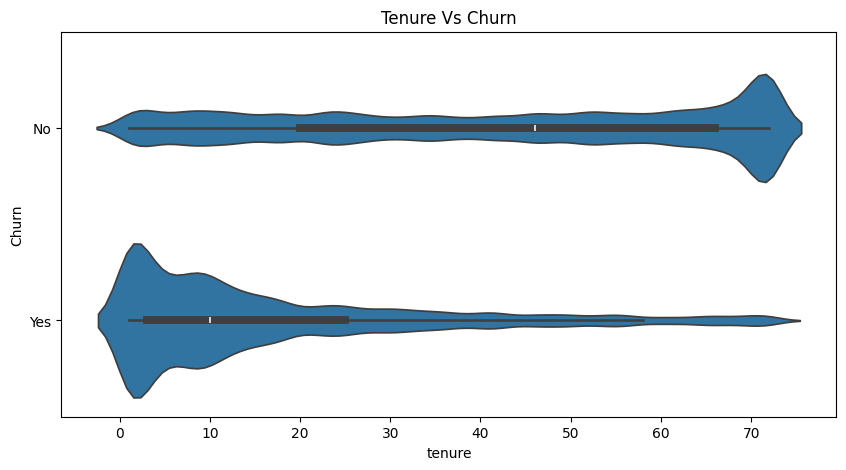

In [42]:
plt.figure(figsize=(10,5))
sns.violinplot(x='tenure',y='Churn',data=data)
plt.title('Tenure Vs Churn')
plt.show()

**Insights:**
New customers (0-10 months) have the highest churn risk, whereas long-term customers (2+years) are highly loyal. The first few months are critical for retention.

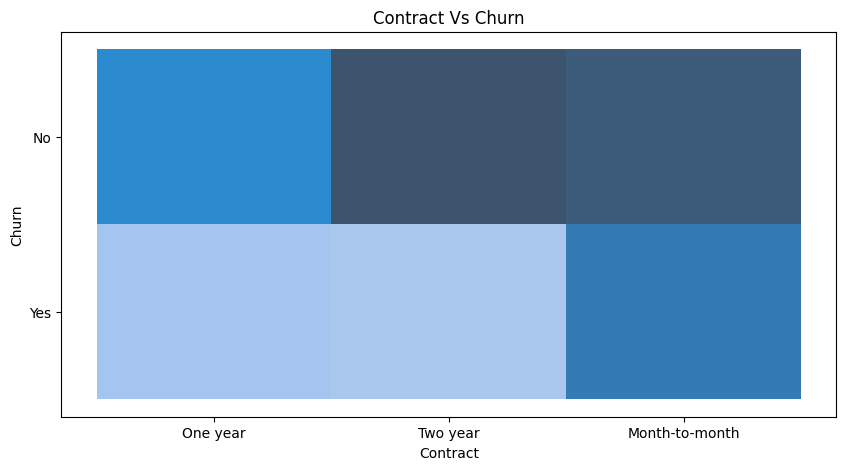

In [43]:
plt.figure(figsize=(10,5))
sns.histplot(x='Contract',y='Churn',data=data)
plt.title('Contract Vs Churn')
plt.show()

**Insights:**
Customers on month to month contracts have the highest churn, while 1-year and especially 2-year contracts show almost no churn. Longer contracts strongly drive customer loyalty.

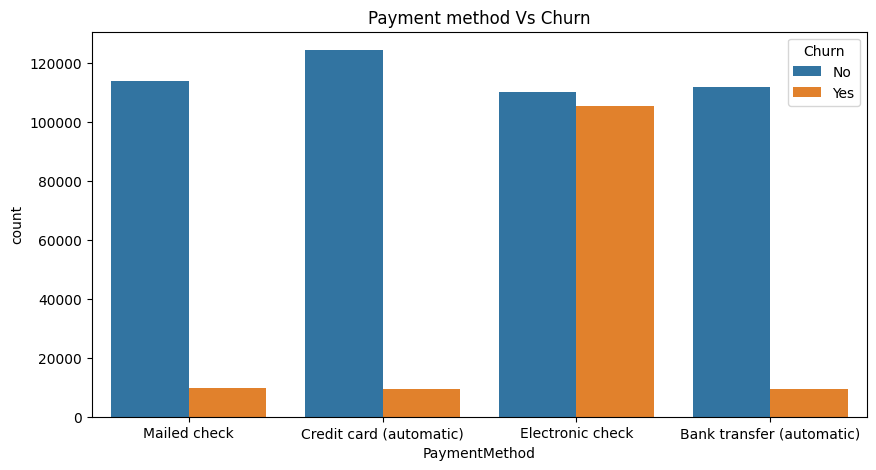

In [44]:
plt.figure(figsize=(10,5))
sns.countplot(x='PaymentMethod',hue='Churn',data=data)
plt.title('Payment method Vs Churn')
plt.show()

**insights:**
Electronic check users have the highest churn, nearly equal to non-churners, whereas automatic payments(credit card/ bank transfer) have very low churn. pyament method strongly impacts retentions.

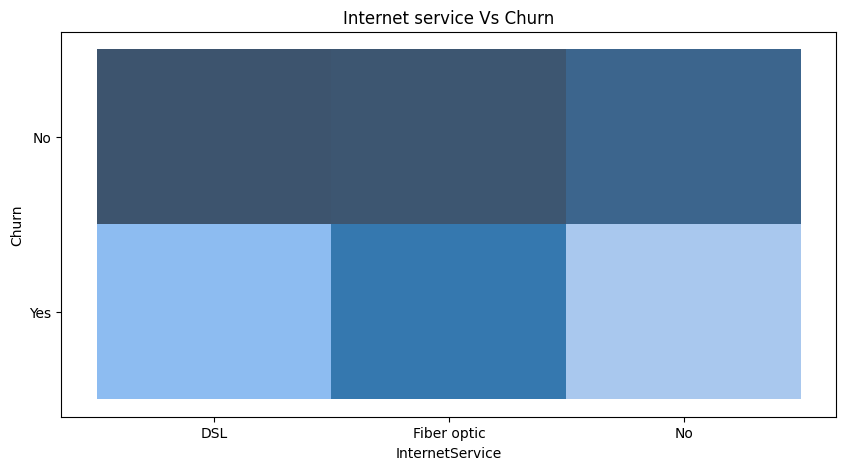

In [45]:
plt.figure(figsize=(10,5))
sns.histplot(x='InternetService',y='Churn',data=data)
plt.title('Internet service Vs Churn')
plt.show()

**Insights:**
Fiber Optic Customers show the highest churn, while customers with no internet service or DSL are more stable. This suggest potentitla issues with fiber service quality or pricing.

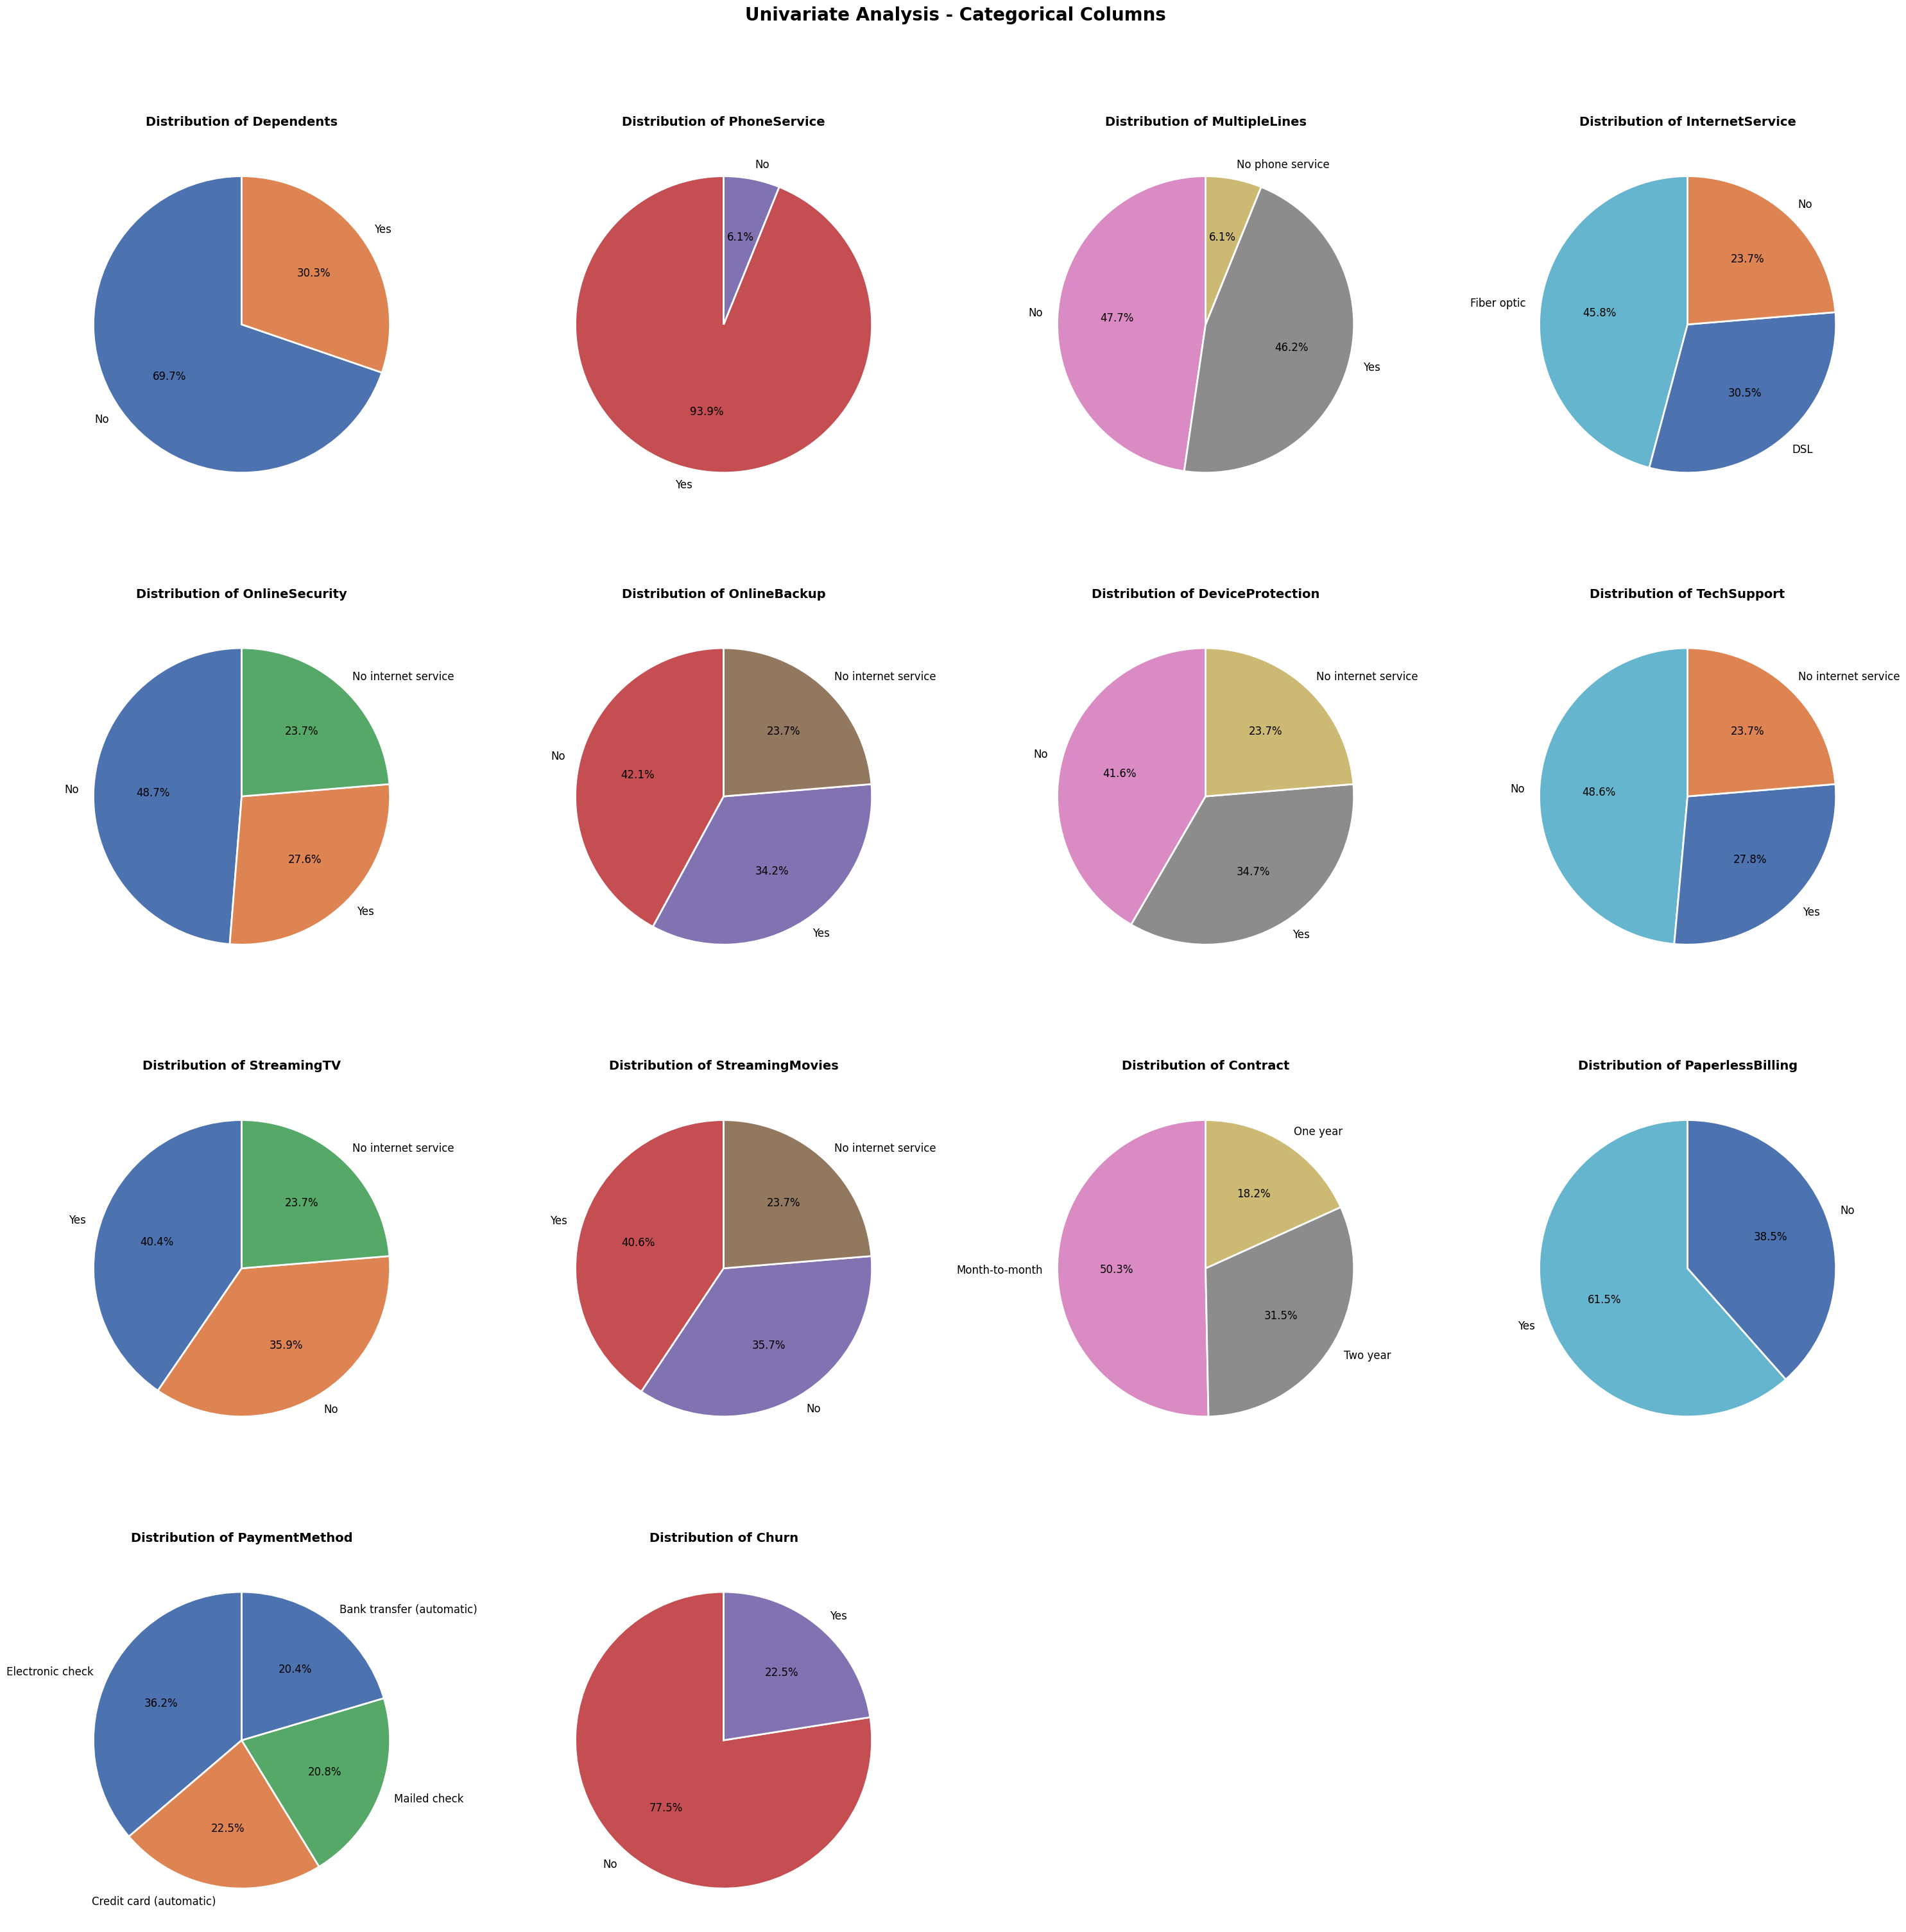

In [46]:
cat_cols = ['Dependents', 'PhoneService', 'MultipleLines', 
            'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 
            'StreamingMovies', 'Contract', 'PaperlessBilling', 
            'PaymentMethod', 'Churn']

fig, axes = plt.subplots(4, 4, figsize=(30, 30))
axes = axes.flatten()

colors = [['#4C72B0','#DD8452','#55A868'],
          ['#C44E52','#8172B2','#937860'],
          ['#DA8BC3','#8C8C8C','#CCB974'],
          ['#64B5CD','#4C72B0','#DD8452']]

for i, col in enumerate(cat_cols):
    vals = data[col].value_counts()
    axes[i].pie(
        vals,
        labels=vals.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors[i % len(colors)],
        wedgeprops={'edgecolor': 'white', 'linewidth': 2},
        textprops={'fontsize': 12}
    )
    axes[i].set_title(f'Distribution of {col}', 
                      fontsize=14, 
                      fontweight='bold', 
                      pad=15)

# Hide empty subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Analysis - Categorical Columns', 
             fontsize=20, 
             fontweight='bold', 
             y=1.02)
plt.tight_layout()
plt.show()

**Insights:**
* Majority of customers don't have add on service (online security, tech support, device protection) indicates low service adoption.
* Month to month contracts dominate (~50%), which aligns with higher churn risk group.
* Fiber optic is the most used internet service, followed by DSL.
* Paperless billing (~61%) is widely adopted, showing customers prefer digital processes.
* Electronic check is the most used payment menthod, which wealready know is linked to higher churn.
* Overall churn is ~22.5%, confirming a moderate imbalance dataset.

**Multivariate Analysis**

In [47]:
# Drop unnecssary columns
data.drop(['id','gender','Partner'],axis=1,inplace=True)

In [48]:
# plt.figure(figsize=(10,5))
# sns.pairplot(data,hue='Churn')
# plt.title('Multivariate Analysis')
# plt.show()

**Insights:**
Key Insights:
* Tenure vs Churn
High concentration of churn (orange points) at low tenure (0–10 months) 
Customers with higher tenure are mostly non-churn → loyal customer base grows over time
* Monthly Charges vs Churn
Churn is higher in high monthly charges range ($70–$100) 
Lower and mid-range charges show fewer churn cases
* Total Charges vs Churn
Customers with low total charges churn more → because they are mostly new customers
High total charges = long-term customers → very low churn
* Tenure vs Total Charges
Strong positive relationship → as tenure increases, total charges increase 
Confirms customer lifetime value grows over time
* Senior Citizen
No strong visible separation → not a major factor influencing churn

**Business Insight:**
* New customers + High monthly charges + Month-to-month contracts = Highest churn risk group 
* Long-term customers + Lower/controlled charges + Long contracts = Most loyal segment 

**Detect Otuliers Using IQR**

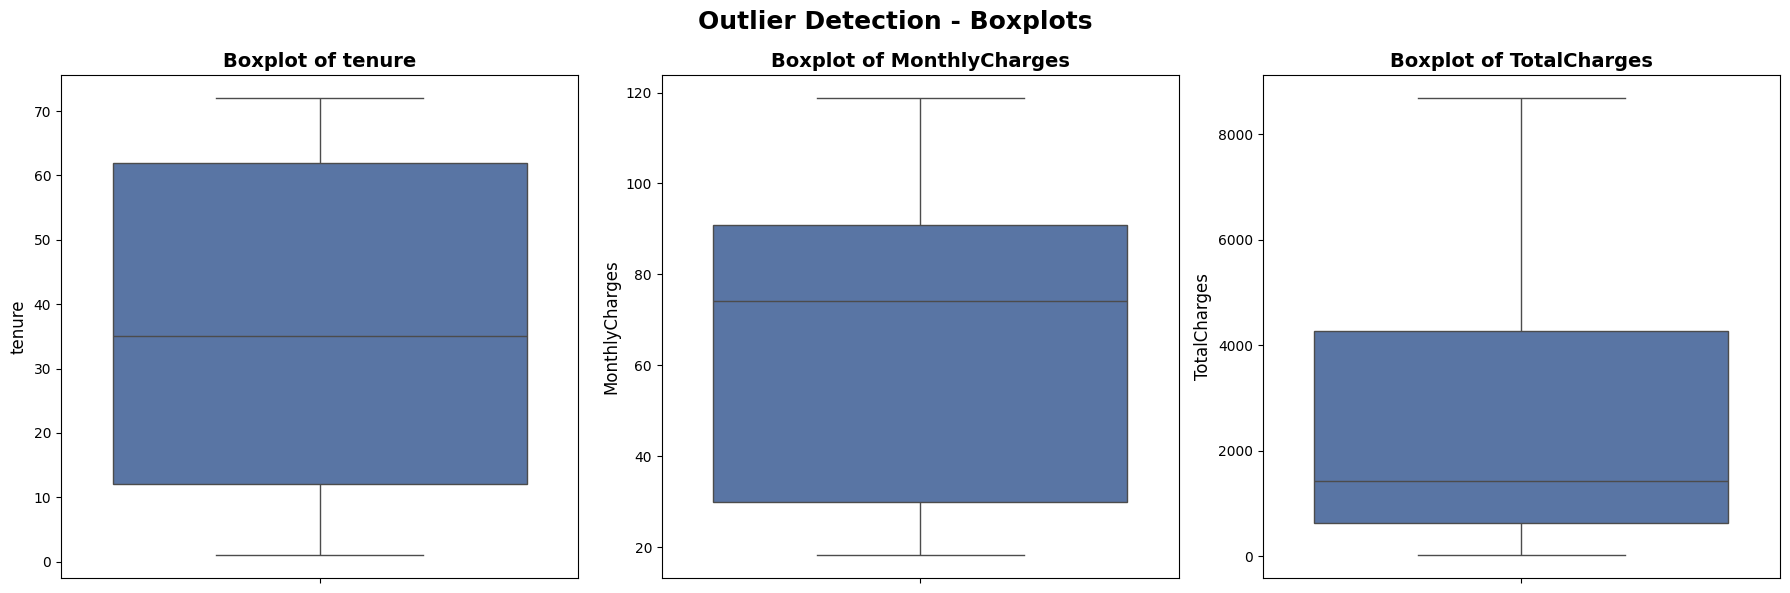

In [49]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(num_cols):
    sns.boxplot(y=data[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(f'Boxplot of {col}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel(col, fontsize=12)
plt.suptitle('Outlier Detection - Boxplots', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

****Insights:****
**Tenure Boxplot:**
* Range: 0 to 72 months
* Median: ~35 months
* IQR: 12 to 61 months — wide spread
* No outliers detected — whiskers reach min/max naturally
  
**MonthlyCharges Boxplot:**
* Range: 20 to 120
* Median: ~70
* IQR: 35 to 90 — wide spread
* No outliers detected — clean distribution
  
**TotalCharges Boxplot:**
* Range: 0 to 8500
* Median: ~1500 — skewed right
* IQR: 400 to 4200 — very wide
* No outliers detected — but heavily right skewed

In [50]:
# Cap Outliers(Winsorization)
for col in  num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower_bound,upper_bound)

**Preprocessing**

In [51]:
# Check total rows
print(f"Total rows: {len(data)}")

# Check Churn unique values
print(data['Churn'].value_counts())

# Check Churn dtype
print(data['Churn'].dtype)

Total rows: 594194
Churn
No     460377
Yes    133817
Name: count, dtype: int64
object


In [52]:
print(data['Churn'].dtype)
print(data['Churn'].unique())
print(data['Churn'].value_counts(dropna=False))

object
['No' 'Yes']
Churn
No     460377
Yes    133817
Name: count, dtype: int64


In [53]:
# Drop null values in the target column in train data
data = data[data['Churn'].notnull()].copy()
# Verify
print(f'shape after remvoing nulls:{data.shape}')
print(f"Null values in Churn: {data['Churn'].isnull().sum()}")
print(data['Churn'].value_counts())

shape after remvoing nulls:(594194, 18)
Null values in Churn: 0
Churn
No     460377
Yes    133817
Name: count, dtype: int64


In [54]:
#Encode the target Column
data['Churn'] = data['Churn'].map({'Yes':1,'No':0})
print(data['Churn'].value_counts())

Churn
0    460377
1    133817
Name: count, dtype: int64


In [55]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = ['Dependents','PhoneService','MultipleLines',
           'InternetService','OnlineSecurity','OnlineBackup',
           'DeviceProtection','TechSupport','StreamingTV',
           'StreamingMovies','Contract','PaperlessBilling','PaymentMethod']
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

**Feature Scaling**


In [56]:
scaler = StandardScaler()
num_cols = ['tenure','MonthlyCharges','TotalCharges']
data[num_cols] = scaler.fit_transform(data[num_cols])

**Train,Test and Split**

In [57]:
X = data.drop('Churn',axis=1)
y = data['Churn']
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

**Model Building**

In [58]:
# Import all the libraries for model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score

In [59]:
models = {
    "LogisticRegression":LogisticRegression(max_iter=1000),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost":XGBClassifier(scale_pos_weight=3,random_state=42)
}

**Model Training**

In [60]:
# Drop the unnecessary columns
data.drop(columns=['id','gender','Partner'],inplace=True)

KeyError: "['id', 'gender', 'Partner'] not found in axis"

**Model Evaluation**

In [63]:
results = []
for name, model in models.items():
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    roc_auc = roc_auc_score(y_test,y_prob)
    results.append({
        'Model':name,
        'Accuracy ': round(accuracy,4),
        'Precision': round(precision,4),
        'Recall': round(recall,4),
        'F1': round(f1,4),
        'ROC-AUC':round(roc_auc,4)
    })
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC',ascending=False)
print(results_df)

                Model  Accuracy   Precision  Recall      F1  ROC-AUC
3             XGBoost     0.8290     0.5832  0.8571  0.6941   0.9162
0  LogisticRegression     0.8529     0.6833  0.6525  0.6676   0.9059
1       Random Forest     0.8436     0.6759  0.5937  0.6322   0.8932
2       Decision Tree     0.8053     0.5699  0.5707  0.5703   0.7258


**Insights:**
From the above results it is clearly shown that XGBoost is peformed well among all the models and achieved good ROC-AUC score,but the recall is 0.64 if we tune this it will improve so we can hypertune the XGBoost Model

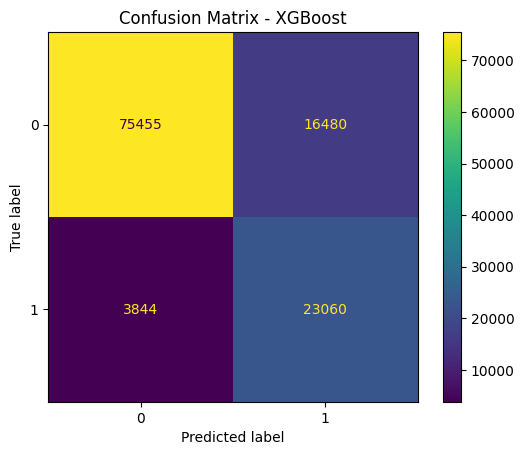

In [64]:
# Add this after model evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix - XGBoost')
plt.show()

**HyperParameter Tuning**

In [ ]:
from sklearn.model_selection import GridSearchCV
params = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.2],
    'subsample':[0.8,1.0],
    'colsample_bytree':[0.8,1.0],
    'scale_pos_weight':[1,3,5]
}
grid = GridSearchCV(
    XGBClassifier(random_state=42),
    params,
    cv = 5,
    scoring = 'recall',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train,y_train)
print(f'Best Params: {grid.best_params_}')
print(f'Best ROC-AUC : {grid.best_score_:.4f}')

In [ ]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]
print(f'Accuracy :{accuracy_score(y_test,y_pred):.4f}')
print(f'Recall : {recall_score(y_test,y_pred):.4f}') 
print(f'F1 score: {f1_score(y_test,y_pred):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test,y_prob):.4f}')

In [67]:
# Default threshold is 0.5 — lower it to catch more churners
y_prob = best_model.predict_proba(X_test)[:, 1]

# Try different thresholds
for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_new = (y_prob >= threshold).astype(int)
    print(f"\nThreshold: {threshold}")
    print(f"Recall   : {recall_score(y_test, y_pred_new):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred_new):.4f}")
    print(f"F1 Score : {f1_score(y_test, y_pred_new):.4f}")

NameError: name 'best_model' is not defined

**Feature Importance**

In [ ]:
# Add this to show which features matter most
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance - XGBoost')
plt.show()

**ROC-AUC Curve**

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Find best threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal Threshold: {optimal_threshold:.4f}")

# Apply optimal threshold
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)
print(f"Recall   : {recall_score(y_test, y_pred_optimal):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_optimal):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_optimal):.4f}")

**Predict the Result on Test Data**

In [ ]:
test.head()

In [ ]:
# Manually map categorical columns so check unique values first
for col in test.select_dtypes(include='object').columns:
    print(f'{col}:{test[col].unique()}')

In [ ]:
# Encode the test data using pandas get dummies
cat_cols = ['Dependents','PhoneService','MultipleLines',
           'InternetService','OnlineSecurity','OnlineBackup',
           'DeviceProtection','TechSupport','StreamingTV',
           'StreamingMovies','Contract','PaperlessBilling',
           'PaymentMethod']
le_test = LabelEncoder()
for col in cat_cols:
    test[col] = le_test.fit_transform(test[col])


In [ ]:
# Scaling
num_cols = ['tenure','MonthlyCharges','TotalCharges']
test[num_cols] = scaler.transform(test[num_cols])
print(test.dtypes)

In [ ]:
test_predictions = best_model.predict_proba(test.drop('id',axis=1))[:,1]
submission = pd.DataFrame({
    'id':test['id'],
    'Churn':test_predictions
})
submission.to_csv('submission.csv',index=False)
print('Submission ready')
print(submission.head())